In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_final = pd.read_csv('Data_for_modelling.csv')

In [3]:
# Set a clean, professional theme for your visualizations
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

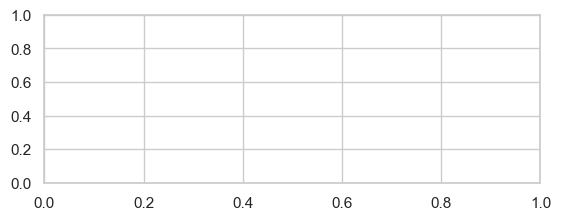

In [4]:
# 1. Heatmap: Correlation between Core Financials and your new Ratios
plt.subplot(2, 1, 1)
core_metrics = ['Revenue', 'Total_Acquisition_Cost', 'Net_Profit', 'ROI', 'CTR', 'Conversion_Rate', 'CPC', 'CPL']
correlation_matrix = df_final[core_metrics].corr()

Text(0.5, 1.0, 'Correlation Matrix: Financial Targets vs. Engineered Ratios')

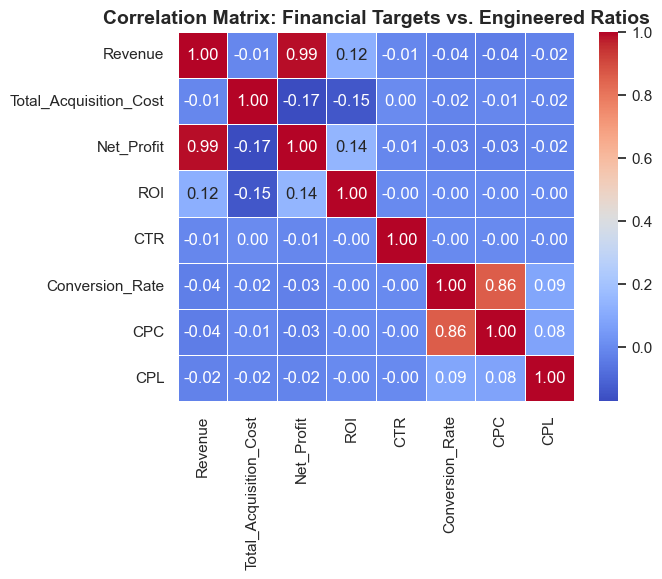

In [5]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Financial Targets vs. Engineered Ratios', fontsize=14, fontweight='bold')

Text(0.5, 0, 'CPC ($)')

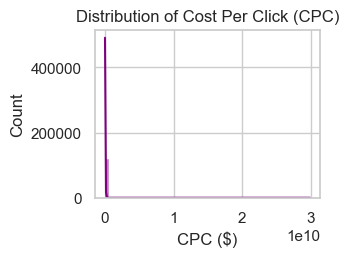

In [6]:
# 2. Distribution Plot: Look for data skew in cost efficiency (CPC)
plt.subplot(2, 2, 3)
sns.histplot(df_final['CPC'], bins=50, kde=True, color='purple')
plt.title('Distribution of Cost Per Click (CPC)', fontsize=12)
plt.xlabel('CPC ($)')

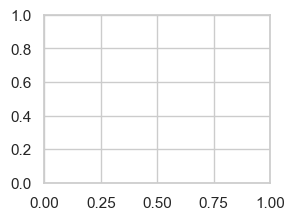

In [7]:
# 3. Bar Plot: Which channel drives the highest average revenue?
plt.subplot(2, 2, 4)
channels = ['Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']
avg_revenue_per_channel = [df_final[df_final[ch] == 1]['Revenue'].mean() for ch in channels]

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Email'),
  Text(1, 0, 'Facebook'),
  Text(2, 0, 'Google'),
  Text(3, 0, 'Instagram'),
  Text(4, 0, 'WhatsApp'),
  Text(5, 0, 'YouTube')])

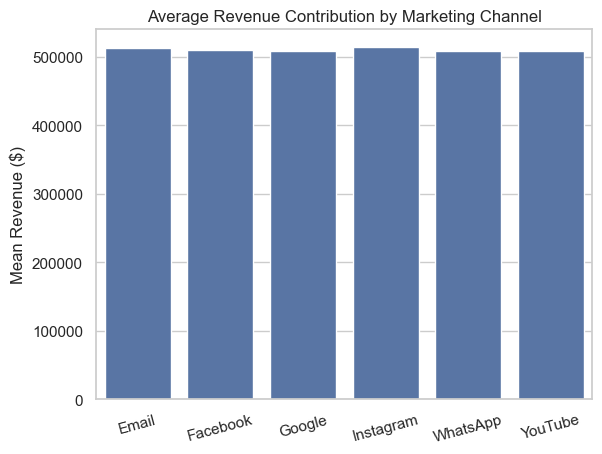

In [10]:
sns.barplot(x=channels, y=avg_revenue_per_channel)
plt.title('Average Revenue Contribution by Marketing Channel', fontsize=12)
plt.ylabel('Mean Revenue ($)')
plt.xticks(rotation=15)

In [9]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

C:\Users\Puneeth\AppData\Local\Temp\ipykernel_24144\3937597024.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channels, y=avg_revenue_per_channel, palette='viridis')


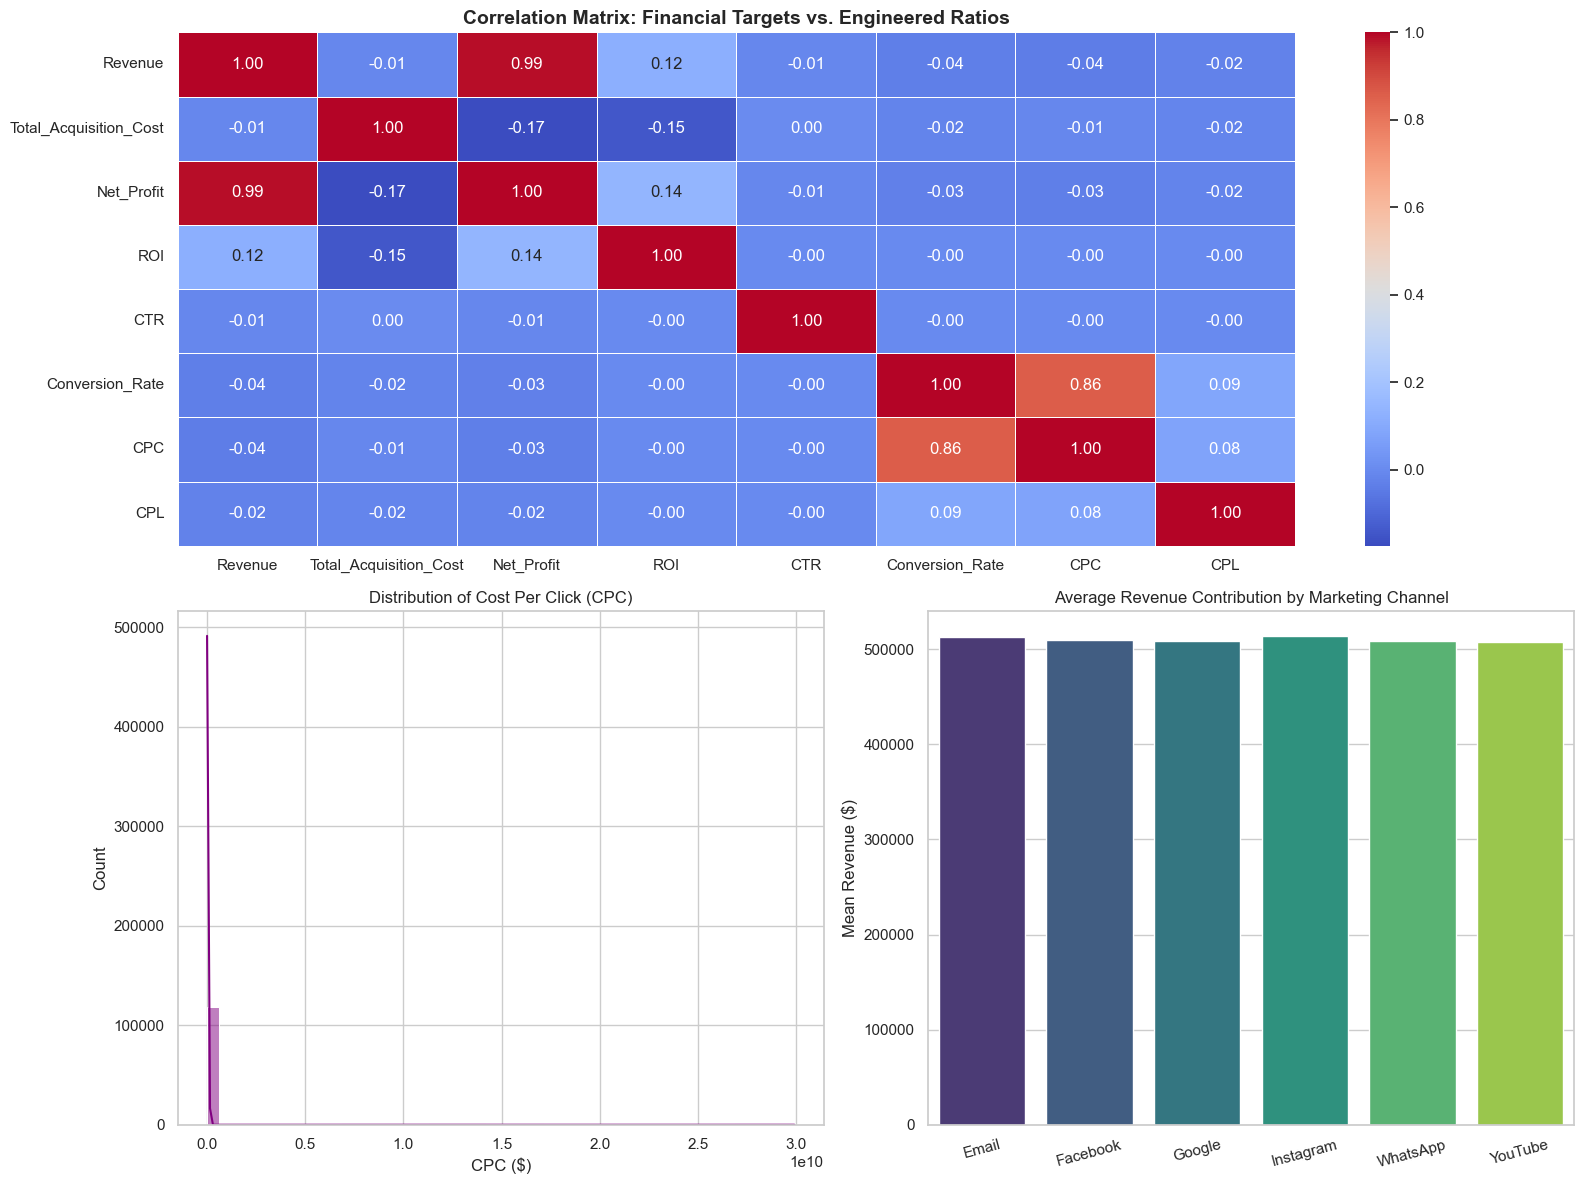

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional theme for your visualizations
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Heatmap: Correlation between Core Financials and your new Ratios
plt.subplot(2, 1, 1)
core_metrics = ['Revenue', 'Total_Acquisition_Cost', 'Net_Profit', 'ROI', 'CTR', 'Conversion_Rate', 'CPC', 'CPL']
correlation_matrix = df_final[core_metrics].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Financial Targets vs. Engineered Ratios', fontsize=14, fontweight='bold')

# 2. Distribution Plot: Look for data skew in cost efficiency (CPC)
plt.subplot(2, 2, 3)
sns.histplot(df_final['CPC'], bins=50, kde=True, color='purple')
plt.title('Distribution of Cost Per Click (CPC)', fontsize=12)
plt.xlabel('CPC ($)')

# 3. Bar Plot: Which channel drives the highest average revenue?
plt.subplot(2, 2, 4)
channels = ['Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']
avg_revenue_per_channel = [df_final[df_final[ch] == 1]['Revenue'].mean() for ch in channels]

sns.barplot(x=channels, y=avg_revenue_per_channel, palette='viridis')
plt.title('Average Revenue Contribution by Marketing Channel', fontsize=12)
plt.ylabel('Mean Revenue ($)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Log(CPC + 1)')

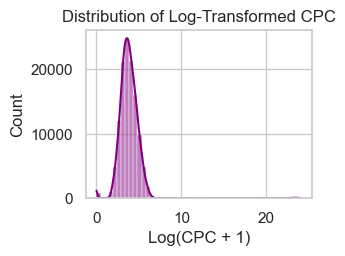

In [12]:
# 2. Distribution Plot: Applied log transformation to handle extreme skew
plt.subplot(2, 2, 3)
import numpy as np
# np.log1p handles log(0) safely by calculating log(1 + x)
sns.histplot(np.log1p(df_final['CPC']), bins=50, kde=True, color='purple')
plt.title('Distribution of Log-Transformed CPC', fontsize=12)
plt.xlabel('Log(CPC + 1)')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Email'),
  Text(1, 0, 'Facebook'),
  Text(2, 0, 'Google'),
  Text(3, 0, 'Instagram'),
  Text(4, 0, 'WhatsApp'),
  Text(5, 0, 'YouTube')])

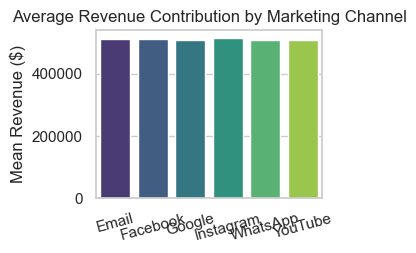

In [13]:
# 3. Bar Plot: Fixed the palette warning by explicitly setting hue
plt.subplot(2, 2, 4)
channels = ['Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']
avg_revenue_per_channel = [df_final[df_final[ch] == 1]['Revenue'].mean() for ch in channels]

sns.barplot(x=channels, y=avg_revenue_per_channel, hue=channels, palette='viridis', legend=False)
plt.title('Average Revenue Contribution by Marketing Channel', fontsize=12)
plt.ylabel('Mean Revenue ($)')
plt.xticks(rotation=15)

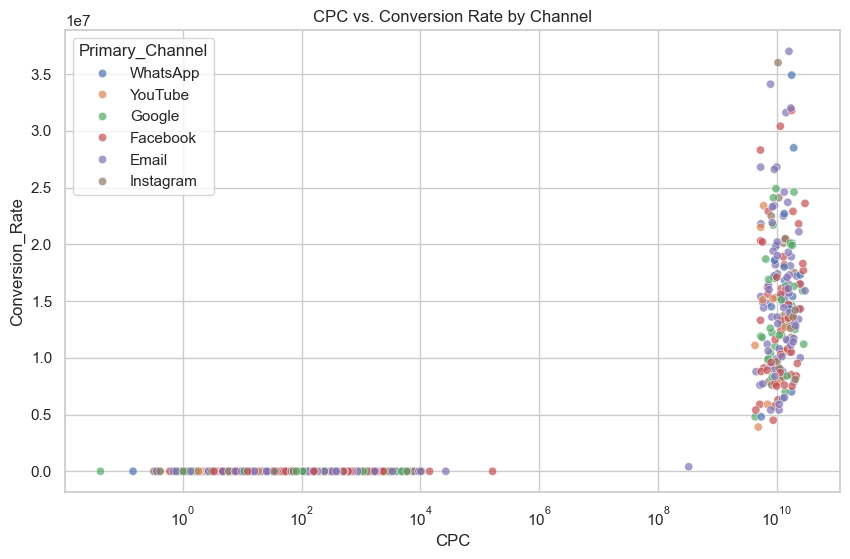

In [14]:
# Investigate the relationship between CPC and Conversion Rate across channels
plt.figure(figsize=(10, 6))

# Melt the channel columns back into a single categorical column for visualization
channel_cols = ['Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']
df_melted = df_final.copy()
df_melted['Primary_Channel'] = df_melted[channel_cols].idxmax(axis=1)

sns.scatterplot(data=df_melted, x='CPC', y='Conversion_Rate', hue='Primary_Channel', alpha=0.7)
plt.title('CPC vs. Conversion Rate by Channel')
plt.xscale('log') # Using log scale due to the extreme CPC outliers
plt.show()